<a href="https://colab.research.google.com/github/SarahPauwels-ucll/prog_for_data_analysis/blob/main/load_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing the required libraries**

In [1]:
# importing the necessary libraries for data analysis
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

## **Cloning the GitHub Repository:**


This sets the 'user.name' and 'user.email' properties in the global Git configuration file.
These values are used for identifying the author of commits.

In [2]:
! git config --global user.name "SarahPauwels-ucll"

These are variables for the GitHub username, repository namewhich are used for accessing and interacting with the repository.

This command clones the GitHub repository using provided credentials.

In [3]:
username = "SarahPauwels-ucll"
repo = "prog_for_data_analysis"


In [4]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'prog_for_data_analysis'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 27 (delta 5), reused 17 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 8.38 MiB | 17.51 MiB/s, done.
Resolving deltas: 100% (5/5), done.


This command changes the current working directory to the specified repository folder.

In [5]:
%cd {repo}

/content/prog_for_data_analysis


This command lists all files and directories within the current working directory.

In [6]:
%ls

data/  load_data.ipynb  README.md


In [7]:
%cd data/

/content/prog_for_data_analysis/data


## **Task 1 - Data Selection & Handling**

### **Objective :**

* Select 2 inner (urban) and 2 outer (suburban) stations
* Download the four selected datasets
* Import them into your development environment.
* Merge them into a single unified dataset for analysis

The first step is to chose 2 inner and 2 outer stations that we will use for this assigment. The Xu&
Zhang(2004) mentiond that even though all stations had high data availability, the AT station still had only 68% in hourly PM2.5 in 2013. To make our analysis as accurate as possible it's important that we have accurate data there for we will chose the 2 inner and 2 outer stations that have the least amount of missing data.

To do this we put all the data in github. By cloning github(in the previous step) all the data should be in the working directory. We then need to combine them into one data frame so that we can compare the missing values per station.

### **Merging of the csv files:**
---

In [8]:
# Import the necessary libraries
import pandas as pd  # pandas is used for working with data tables
import glob         # glob is used to find files by name patterns

# STEP 1: find all the city files
city_files = glob.glob("PRSA_Data_*.csv")
print(city_files)

# STEP 2: Create an empty list to store all our city data
# We'll put each city's data in this list before combining them
all_cities_data = []

# STEP 3: Read each city file one by one
for file_name in city_files:

    # Read the current city's CSV file into a DataFrame
    # A DataFrame is like a spreadsheet table in Python
    city_df = pd.read_csv(file_name)

    # Add this city's data to our list
    all_cities_data.append(city_df)

    # Optional: Print which file we just read
    print(f"Loaded: {file_name}")

# STEP 4: Combine all city data into one big table
# pd.concat() joins all the DataFrames in our list together
# ignore_index=True makes sure the row numbers are continuous (0, 1, 2, 3...)
combined_data = pd.concat(all_cities_data, ignore_index=True)

# STEP 5: Save the combined data to a new CSV file
# index=False means don't save the row numbers as a separate column
combined_data.to_csv("all_cities_combined.csv", index=False)

# STEP 6: Show us what we accomplished
# len(city_files) = count of how many city files we combined
# len(combined_data) = total number of rows in the final combined file
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

['PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv']
Loaded: PRSA_Data_Shunyi_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv
Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Nongzhanguan_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Tiantan_20130301-20170228.csv
Loaded: PRSA_Data_Aotizhongxin_20130301-20170228.csv
Loaded: PRSA_Data_Wans

In [9]:
alldf= pd.read_csv('all_cities_combined.csv')
alldf

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,27.0,4.0,20.0,300.0,81.0,12.6,1011.9,-14.3,0.0,N,2.0,Wanliu
420764,35061,2017,2,28,20,15.0,43.0,6.0,55.0,500.0,45.0,9.4,1012.3,-11.9,0.0,WSW,1.0,Wanliu
420765,35062,2017,2,28,21,13.0,35.0,7.0,48.0,500.0,48.0,8.7,1012.8,-13.7,0.0,N,1.1,Wanliu
420766,35063,2017,2,28,22,12.0,31.0,5.0,47.0,500.0,50.0,7.8,1012.9,-12.6,0.0,NNE,1.0,Wanliu


/tmp/ipykernel_3622/1088413817.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_data = df.groupby('station').apply(lambda x: x.isnull().mean() * 100)


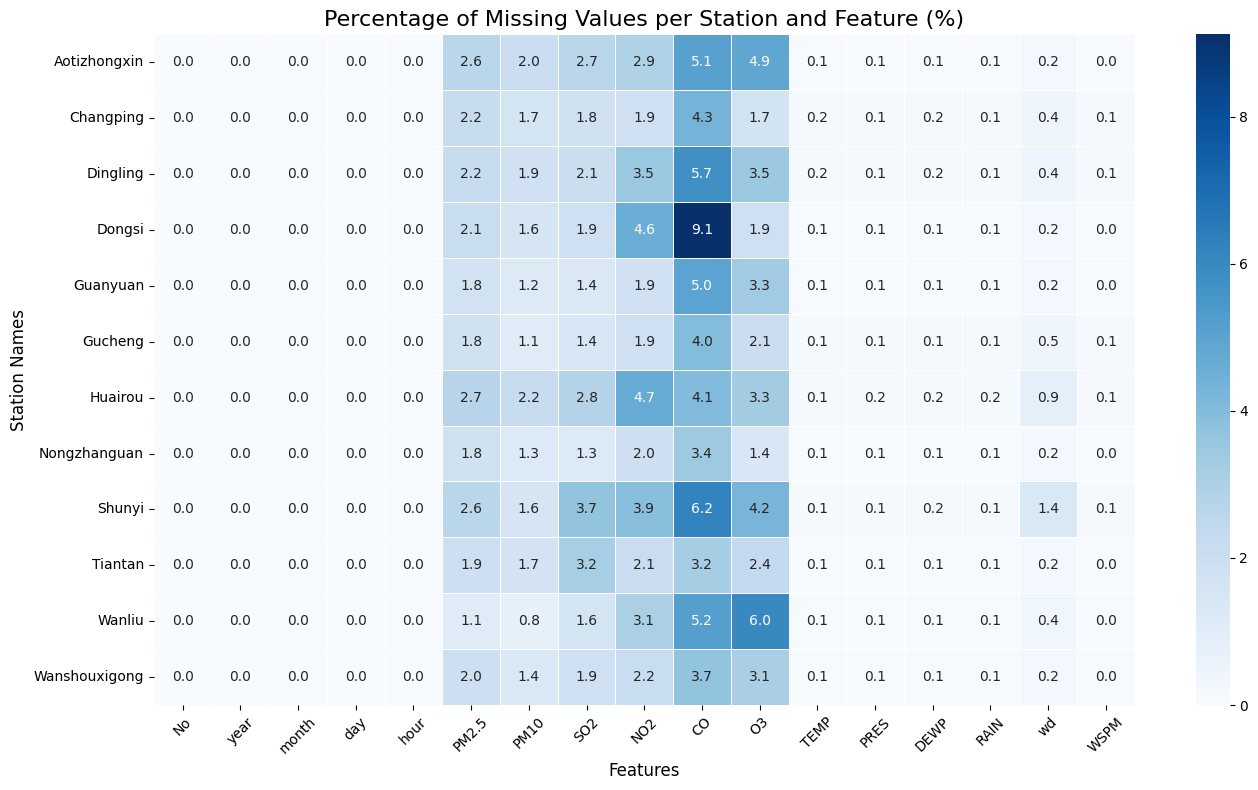

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_missing_values_heatmap(df):
    # Calculate percentage of missing values per group (station) per column
    missing_data = df.groupby('station').apply(lambda x: x.isnull().mean() * 100)

    # 2. Remove the group_col from the columns since its missing value count is irrelevant
    if 'station' in missing_data.columns:
        missing_data = missing_data.drop(columns=['station'])

    # 3. Create the heatmap plot
    plt.figure(figsize=(14, 8))
    sns.heatmap(missing_data, annot=True, cmap='Blues', fmt=".1f", linewidths=.5)

    plt.title('Percentage of Missing Values per Station and Feature (%)', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Station Names', fontsize=12)
    plt.xticks(rotation=45)      # Rotate x labels for better readability
    plt.tight_layout()

    plt.show()

plot_missing_values_heatmap(alldf)

for the outer stations we need to chose between Changpingzhen, Dingling, Huairouzhen and Shunyixincheng. by looking at the heatmap we can see that **Changpingzhen** has the least amount of missing values over all the features. Huairouzhen has more missing values for NO2 than Dingling, but it has more values for CO and O3 so we chose **Huairouzhen.**

for the inner stations we need to chose between Aotizhongxin, Dongsi, Guanyuan, Nongzhanguan, Tiantan,Wanshouxigong, Gucheng and
Haidianquwanliu. here we chose **Nongzhanguan and Gucheng**

Then we have to merge them into a single unified dataset for analysis.

In [13]:
selected_stations = ['Nongzhanguan', 'Tiantan', 'Huairou', 'Gucheng']

#this keeps only rows where the 'station' column selected
selecteddf = alldf[alldf['station'].isin(selected_stations)]

selecteddf.to_csv("selected_combined.csv", index=False)

load the data in.

In [37]:
df= pd.read_csv('selected_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


Check if the merge of the 4 stations was correct.

In [22]:
stations = df['station'].value_counts()
print(f'Total number of stations in the dataset : {len(stations)}')
stations

Total number of stations in the dataset : 4


,count
station,
Nongzhanguan,35064
Gucheng,35064
Tiantan,35064
Huairou,35064


## **Task 2: Exploratory Data Analysis (EDA)**
## **2.1.Data Understanding**

### **Objective :**
Provide an overview that may include the following, but not limited to:
* Number of rows and columns
* Column descriptions
* Data types
* Missing values
* Statistical Summary
* Initial observations & interpretation

In [16]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [17]:
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou
140255,35064,2017,2,28,23,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,NE,1.9,Huairou


In [18]:
df.shape
print(f'No of Rows: {df.shape[0]}, No of Columns: {df.shape[1]}')

No of Rows: 140256, No of Columns: 18


In [21]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137352 non-null  float64
 6   PM10     138061 non-null  float64
 7   SO2      137205 non-null  float64
 8   NO2      136513 non-null  float64
 9   CO       135101 non-null  float64
 10  O3       137027 non-null  float64
 11  TEMP     140114 non-null  float64
 12  PRES     140113 non-null  float64
 13  DEWP     140112 non-null  float64
 14  RAIN     140118 non-null  float64
 15  wd       139639 non-null  object 
 16  WSPM     140137 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB


In [29]:
df['wd'].unique()

array(['NNW', 'NW', 'N', 'W', 'ENE', 'NE', 'E', 'NNE', 'SW', 'SSW', 'S',
       'WSW', 'ESE', 'SE', 'WNW', 'SSE', nan], dtype=object)

| Column | Description |Typical Unit |
| :--- | :--- | :--- |
| **PM2.5** | Fine Particulate Matter | $\mu g/m^3$ |
| **PM10** | Fine/Coarse Particulate Matter <br> (PM2.5 is included in PM10 to just find coarse particulare matter you need to exclude PM2.5 from PM10) | $\mu g/m^3$ |
| **SO2** | Sulfur Dioxide | $\mu g/m^3$ |
| **NO2** | Nitrogen Dioxide| $\mu g/m^3$ |
| **O3** |  Ozone | $\mu g/m^3$ |
| **CO** | Carbon Monoxide | $mg/m^3$  |
| **TEMP** | Temperature | $^\circ$C |
| **DEWP** | Dew Point Temperature| $^\circ$C |
| **PRES** | Barometric Pressure | hPa |
| **RAIN** | Hourly Precipitation | mm |
| **WSPM** | Wind Speed | m/s |
| **Wd** | Wind Direction |  |

### **missing values**

In [23]:
def missing_values_table(df):
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(df)
display(missing_values.style.background_gradient(cmap='Blues'))

,Missing Values,% of Total Values
CO,5155,3.675422
NO2,3743,2.668692
O3,3229,2.302219
SO2,3051,2.175308
PM2.5,2904,2.070500
PM10,2195,1.564995
wd,617,0.439910
DEWP,144,0.102669
PRES,143,0.101956
TEMP,142,0.101243


In [28]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


In [26]:
df.describe().T #transposed for beter readablility

,count,mean,std,min,25%,50%,75%,max
No,140256.0,17532.500000,10122.141000,1.0000,8766.75,17532.5,26298.25,35064.0
year,140256.0,2014.662560,1.177201,2013.0000,2014.00,2015.0,2016.00,2017.0
month,140256.0,6.522930,3.448715,1.0000,4.00,7.0,10.00,12.0
day,140256.0,15.729637,8.800123,1.0000,8.00,16.0,23.00,31.0
hour,140256.0,11.500000,6.922211,0.0000,5.75,11.5,17.25,23.0
PM2.5,137352.0,80.144075,80.736633,2.0000,21.00,56.0,111.00,844.0
PM10,138061.0,106.466717,91.968006,2.0000,37.00,84.0,148.00,995.0
SO2,137205.0,15.151537,21.370441,0.2856,2.00,7.0,18.00,500.0
NO2,136513.0,50.027617,34.612192,1.0265,23.00,43.0,70.00,276.0
CO,135101.0,1242.562216,1146.399290,100.0000,500.00,900.0,1500.00,10000.0


By looking at the data we can see that there are 4 colums that tell us when they took the mesurement. We could make this into one colum.

there are no duplicates in this data set so we don't need to worry about that, however there is missing data. We will have to lookinto this and see how we can best fill this data.

Since PM10 includes PM2.5 we could make a new colum so the colum are not impacted by eachother and make a 2.5-10 colum that displays only the particals that are smaler then 10 but still larger than 2.5.


## **Task 2: Exploratory Data Analysis (EDA)**
## **2.2.Data preprocessing:**

### **Objective :**
Perform the necessary data preprocessing steps, including but not limited to handling missing values,
removing duplicate entries, feature engineering (e.g., datetime components, AQI levels), and overall data
cleaning on the main dataset.

Making a new feature that only displays the Coarse Particulate Matter

In [43]:
df['PM2.5-10'] = df['PM10'] - df['PM2.5']
#is should never be lower then 0 if lower than there is a calibration issue
df['PM2.5-10'] = df['PM2.5-10'].clip(lower=0)

#**fill missing colums**
the most accurate way to fill most of the missing values in this data set is to use linear interpolation. This is because 'PM2.5', 'PM10', 'SO2', 'NO2', 'O3' and 'CO' are all values that display polution and polution builds up and clears up gradually.

'TEMP', 'PRES', 'WSPM'and'DEWP' display the weather and the weather usually also changes gradually so here we use linear interpolation aswell. However if we look at rain specificaly we can see that almost all the values are zero. Therefor I chose to fill the missing rain values with 0.

the WD also usually doesn't change imedatly, but it is catogorical data, therefor I chose to forward fill.

In [31]:

numeric_cols = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO', 'TEMP', 'PRES', 'WSPM','DEWP']
df[numeric_cols] = df.groupby('station')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both'))

df['wd'] = df.groupby('station')['wd'].ffill()

df = df.fillna({'RAIN': 0})

df.isnull().sum()

,0
No,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0
DEWP,0


There are no duplicates so there is no need to remove them

**Make 1 datetime colum**

In [27]:
import pandas as pd

# Create the new datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Drop the old columns
df = df.drop(columns=['year', 'month', 'day', 'hour'])

#verify
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan,2013-03-01 00:00:00
1,2,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan,2013-03-01 01:00:00
2,3,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan,2013-03-01 02:00:00
3,4,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan,2013-03-01 03:00:00
4,5,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan,2013-03-01 04:00:00


In [ ]:
df = df.drop(columns=['PM10','NO'])

## **Task 2: Exploratory Data Analysis (EDA)**
## **2.3.Statistical/Computational Analysis & Visualisation**

### **Objective :**
* Perform the necessary steps such as univariate (distribution of pollutants & meteorological variables),
bivariate(e.g. relationships such as PM2.5 vs. Temp, NO2 vs. O3 but not limited to these), and
multivariate analysis (correlation, heatmaps, pairplots), statistical summary, and visualizing the data
(Various charts and graphs, such as bar charts, line charts and scatter plots) that will help in
understanding relationships between variables and to gain important insights from data. Interpret the
key results to demonstrate understanding generated from statistical and visual analysis.
* Explore the dataset however you find meaningful. You may examine different variables, compare
stations, investigate temporal behaviours, or analyse interactions between pollutants and
meteorological factors. Choose the approaches that you believe best help you understand and interpret
the dataset, and present the insights you consider most relevant



## **Task 3: Model Building:**

### **Objective :**
* After completing all the tasks listed under Task 1 and Task 2, identify and implement the best practices
to build a suitable machine-learning model (e.g., feature scaling, encoding techniques, variable selection,
and parameter optimization).
* Justify your modelling decisions and evaluate model performance using appropriate metrics.

## **Task 4: Application Development**
 Develop an interactive application with a graphical user interface (GUI).

### **Objective :**
The dataset section,
* Visualization section, and
* Model outputs section

In [1]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.7 MB/s eta 0:00:00


In [2]:
!pip install --upgrade Streamlit

In [3]:
import streamlit as st

In [4]:
%%writefile streamlit_app.py
# import module

import streamlit as st

# Title
st.title("Hello world")


Writing streamlit_app.py


## **Task 5: Version Control:**
### **Objective :**
* Use GitHub for version control.
* Commit changes regularly with clear, descriptive messages, for example, added PM2.5 prediction
model”, “Created correlation heatmap,” etc.
* Maintain an organised repository structure and include screenshots of:
* GitHub commit history
* GitHub project repository layout